# 📡 Spatio-Temporal Analysis of SAR Imagery using Deep Learning and Autoencoder-Based Feature Learning

---

## 📌 Project Overview
This project implements a machine learning and deep learning pipeline for analyzing **Synthetic Aperture Radar (SAR)** imagery from the **Sen1Floods11** dataset. 
SAR sensors (like Sentinel-1) send microwave pulses and measure the backscattered signal. Because microwaves penetrate clouds and are independent of sunlight, SAR is highly effective for flood mapping, environmental monitoring, and change detection.

### 🎯 Objectives
- **Data Loading**: Download and ingest raw dual-polarization Sentinel-1 SAR imagery (VV & VH bands) and ground-truth flood masks.
- **Preprocessing**: Normalize the decibel (dB) backscatter coefficients, clean invalid data, and resize spatial dimensions.
- **Autoencoder**: Train an unsupervised Convolutional Autoencoder (CAE) to reconstruct SAR imagery and learn compressed, spatial representations.
- **Visualization**: Plot reconstructed images, training loss curves, and dual-polarization false-color RGB composites.
- **Feature Extraction**: Extract bottleneck latent representations from the encoder and upsample them to build per-pixel feature vectors.
- **Classification**: Train a Random Forest classifier on pixel-wise features to distinguish flooded land from non-flooded areas.
- **Evaluation**: Measure classification performance using overall accuracy, precision, recall, F1-score, and Intersection over Union (IoU), and visualize predictions.

---
## 🧠 Methodology Workflow
1. **Data Loading** ➔ 2. **Preprocessing** ➔ 3. **Autoencoder** ➔ 4. **Visualization** ➔ 5. **Feature Extraction** ➔ 6. **Classification** ➔ 7. **Evaluation**

### 🛠️ Step 1: Ingesting Dependencies & Libraries
First, we import the necessary libraries, including `rasterio` (for GeoTIFF file handling), `PyTorch` (for the Deep learning autoencoder), and `scikit-learn` (for machine learning classification and validation metrics).

In [1]:
import os
import urllib.request
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score, confusion_matrix
import seaborn as sns

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### 📥 Step 2: Data Loading and Dataset Download
We download a subset of the **Sen1Floods11** hand-labeled dataset. The dataset split files are available as CSV files listing the S1 image and label mask filenames.
To keep training fast and lightweight in a notebook, we will download a subset (e.g., 30 training chips and 10 testing chips) directly from the public Google Cloud Storage bucket.

The dataset features:
- **Sentinel-1 (S1)**: 2 bands representing VV polarization backscatter and VH polarization backscatter.
- **LabelHand**: Pixel-wise ground truth where `0` is non-flood, `1` is flood, and `-1` is invalid/no data (clouds or shadow).

In [2]:
# Create directories for data storage
DATA_DIR = "data/sen1floods11"
S1_DIR = os.path.join(DATA_DIR, "S1Hand")
LABEL_DIR = os.path.join(DATA_DIR, "LabelHand")
os.makedirs(S1_DIR, exist_ok=True)
os.makedirs(LABEL_DIR, exist_ok=True)

# GCS base URLs
BASE_URL = "https://storage.googleapis.com/sen1floods11/v1.1"
SPLIT_BASE_URL = f"{BASE_URL}/splits/flood_handlabeled"
DATA_BASE_URL = f"{BASE_URL}/data/flood_events/HandLabeled"

# Download CSV split files
train_csv_path = os.path.join(DATA_DIR, "flood_train_data.csv")
test_csv_path = os.path.join(DATA_DIR, "flood_test_data.csv")

if not os.path.exists(train_csv_path):
    print("Downloading training split CSV...")
    urllib.request.urlretrieve(f"{SPLIT_BASE_URL}/flood_train_data.csv", train_csv_path)

if not os.path.exists(test_csv_path):
    print("Downloading testing split CSV...")
    urllib.request.urlretrieve(f"{SPLIT_BASE_URL}/flood_test_data.csv", test_csv_path)

def download_subset(csv_path, num_samples):
    """Helper to read CSV split and download a specified number of samples."""
    downloaded_files = []
    with open(csv_path, "r") as f:
        reader = csv.reader(f)
        for i, row in enumerate(reader):
            if i >= num_samples:
                break
            s1_file, label_file = row[0], row[1]
            
            s1_local = os.path.join(S1_DIR, s1_file)
            label_local = os.path.join(LABEL_DIR, label_file)
            
            # Download S1 image
            if not os.path.exists(s1_local):
                print(f"Downloading {s1_file}...")
                urllib.request.urlretrieve(f"{DATA_BASE_URL}/S1Hand/{s1_file}", s1_local)
            
            # Download Label image
            if not os.path.exists(label_local):
                print(f"Downloading {label_file}...")
                urllib.request.urlretrieve(f"{DATA_BASE_URL}/LabelHand/{label_file}", label_local)
                
            downloaded_files.append((s1_local, label_local))
            
    print(f"Successfully verified/downloaded {len(downloaded_files)} file pairs.")
    return downloaded_files

# Download 30 training chips and 10 test chips
print("Processing training subset:")
train_files = download_subset(train_csv_path, 30)

print("\nProcessing testing subset:")
test_files = download_subset(test_csv_path, 10)

Processing training subset:


Successfully verified/downloaded 30 file pairs.

Processing testing subset:


Successfully verified/downloaded 10 file pairs.


### 🧹 Step 3: Preprocessing and Data Loaders
SAR backscatter values are in decibels (dB), which typically range from -50 to +5 dB. To preprocess the data for deep learning:
1. **Clean**: Fill invalid/NaN backscatter values with appropriate constants.
2. **Clip**: Limit the range of VV polarization to `[-30.0, 0.0]` and VH polarization to `[-35.0, -5.0]` to eliminate outliers.
3. **Normalize**: Map the clipped backscatter ranges linearly to `[0, 1]`.
4. **Resize**: Interpolate the raw 512x512 chips to 256x256 to speed up processing on standard systems.
5. **Mask**: Keep the label values (0 = non-flood, 1 = flood, -1 = ignore).

In [3]:
def preprocess_s1(data):
    """Fill NaNs, clip range, and normalize VV (band 0) and VH (band 1) channels to [0, 1]"""
    # Fill NaNs
    vv = np.nan_to_num(data[0], nan=-25.0)
    vh = np.nan_to_num(data[1], nan=-30.0)
    
    # Clip
    vv_clipped = np.clip(vv, -30.0, 0.0)
    vh_clipped = np.clip(vh, -35.0, -5.0)
    
    # Normalize to [0, 1]
    vv_norm = (vv_clipped - (-30.0)) / 30.0
    vh_norm = (vh_clipped - (-35.0)) / 30.0
    
    return np.stack([vv_norm, vh_norm], axis=0)

class Sen1FloodsDataset(Dataset):
    def __init__(self, file_pairs, target_size=(256, 256)):
        self.file_pairs = file_pairs
        self.target_size = target_size
        
    def __len__(self):
        return len(self.file_pairs)
        
    def __getitem__(self, idx):
        s1_path, label_path = self.file_pairs[idx]
        
        # Load S1 image
        with rasterio.open(s1_path) as src:
            s1_data = src.read() # shape: [2, 512, 512]
        
        # Load Label image
        with rasterio.open(label_path) as src:
            label_data = src.read(1) # shape: [512, 512]
            
        # Preprocess S1 backscatter
        s1_preprocessed = preprocess_s1(s1_data)
        
        # Convert to torch tensor for interpolation
        s1_tensor = torch.tensor(s1_preprocessed, dtype=torch.float32).unsqueeze(0) # [1, 2, 512, 512]
        label_tensor = torch.tensor(label_data, dtype=torch.float32).unsqueeze(0).unsqueeze(0) # [1, 1, 512, 512]
        
        # Resize using PyTorch interpolation
        s1_resized = torch.nn.functional.interpolate(
            s1_tensor, size=self.target_size, mode='bilinear', align_corners=False
        ).squeeze(0)
        
        label_resized = torch.nn.functional.interpolate(
            label_tensor, size=self.target_size, mode='nearest'
        ).squeeze(0).squeeze(0).long()
        
        return s1_resized, label_resized

# Create Dataset and DataLoader
train_dataset = Sen1FloodsDataset(train_files)
test_dataset = Sen1FloodsDataset(test_files)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

print(f"Dataset created with {len(train_dataset)} train samples and {len(test_dataset)} test samples.")
sample_img, sample_lbl = train_dataset[0]
print(f"Sample Image Tensor Shape: {sample_img.shape}")
print(f"Sample Label Tensor Shape: {sample_lbl.shape}")

Dataset created with 30 train samples and 10 test samples.


Sample Image Tensor Shape: torch.Size([2, 256, 256])
Sample Label Tensor Shape: torch.Size([256, 256])


### 🧠 Step 4: Autoencoder Model Architecture
We implement a **Convolutional Autoencoder (CAE)** in PyTorch. The goal is to learn unsupervised spatial features from Sentinel-1 images.
- **Encoder**: Compresses the 2-channel normalized input image (`[B, 2, 256, 256]`) down into a low-dimensional bottleneck latent representation (`[B, 128, 16, 16]`).
- **Decoder**: Takes the bottleneck representation and reconstructs the original 2-channel normalized input image (`[B, 2, 256, 256]`).

In [4]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()
        # Encoder: 256x256x2 -> 16x16x128
        self.encoder = nn.Sequential(
            nn.Conv2d(2, 16, kernel_size=3, stride=2, padding=1),  # 128x128x16
            nn.ReLU(True),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 64x64x32
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # 32x32x64
            nn.ReLU(True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # 16x16x128
            nn.ReLU(True)
        )
        # Decoder: 16x16x128 -> 256x256x2
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1), # 32x32x64
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # 64x64x32
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # 128x128x16
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 2, kernel_size=3, stride=2, padding=1, output_padding=1),   # 256x256x2
            nn.Sigmoid() # Scale output between [0, 1]
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent

# Instantiate the model, optimizer, and loss function
model = ConvAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(2, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(16, 2, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (

### 🏋️‍♂️ Step 5: Training the Autoencoder
We train the autoencoder unsupervised for 15 epochs. We track the reconstruction loss and visualize how the model learns to compress and reconstruct the radar patterns.

In [5]:
num_epochs = 15
loss_history = []

print("Starting Autoencoder training...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for data, _ in train_loader:
        data = data.to(device)
        
        # Forward pass
        reconstructed, _ = model(data)
        loss = criterion(reconstructed, data)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * data.size(0)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    loss_history.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.5f}")

print("Autoencoder training complete!")

Starting Autoencoder training...


Epoch [1/15], Loss: 0.03498


Epoch [2/15], Loss: 0.02642


Epoch [3/15], Loss: 0.01846


Epoch [4/15], Loss: 0.01497


...

Epoch [11/15], Loss: 0.01158


Epoch [12/15], Loss: 0.01068


Epoch [13/15], Loss: 0.01075


Epoch [14/15], Loss: 0.01031


Epoch [15/15], Loss: 0.01007
Autoencoder training complete!


### 🎨 Step 6: Visualization
To qualitatively evaluate our autoencoder, we plot the training loss curve and visualize original vs. reconstructed images.
Since SAR imagery is in greyscale (VV or VH), we can create a **dual-polarization false-color composite** which makes surface water stand out:
- **Red channel**: VV polarization
- **Green channel**: VH polarization
- **Blue channel**: VV / VH ratio (represented as `VV - VH` in normalized space)
In this visualization, flat open water reflects away most signal (specular reflection), showing up as dark/black regions, whereas vegetation reflects heavily (volume scattering), creating high contrast.

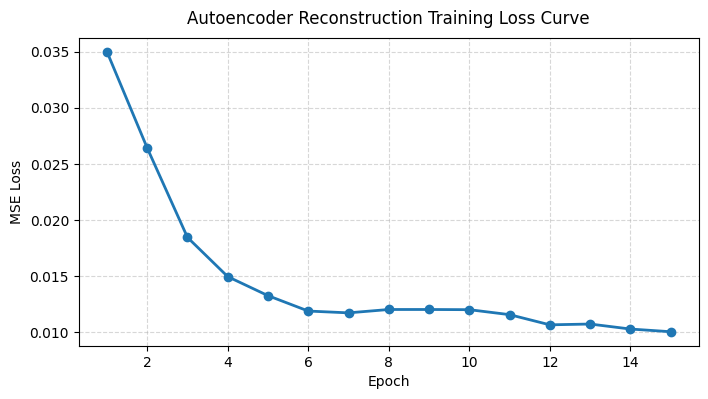

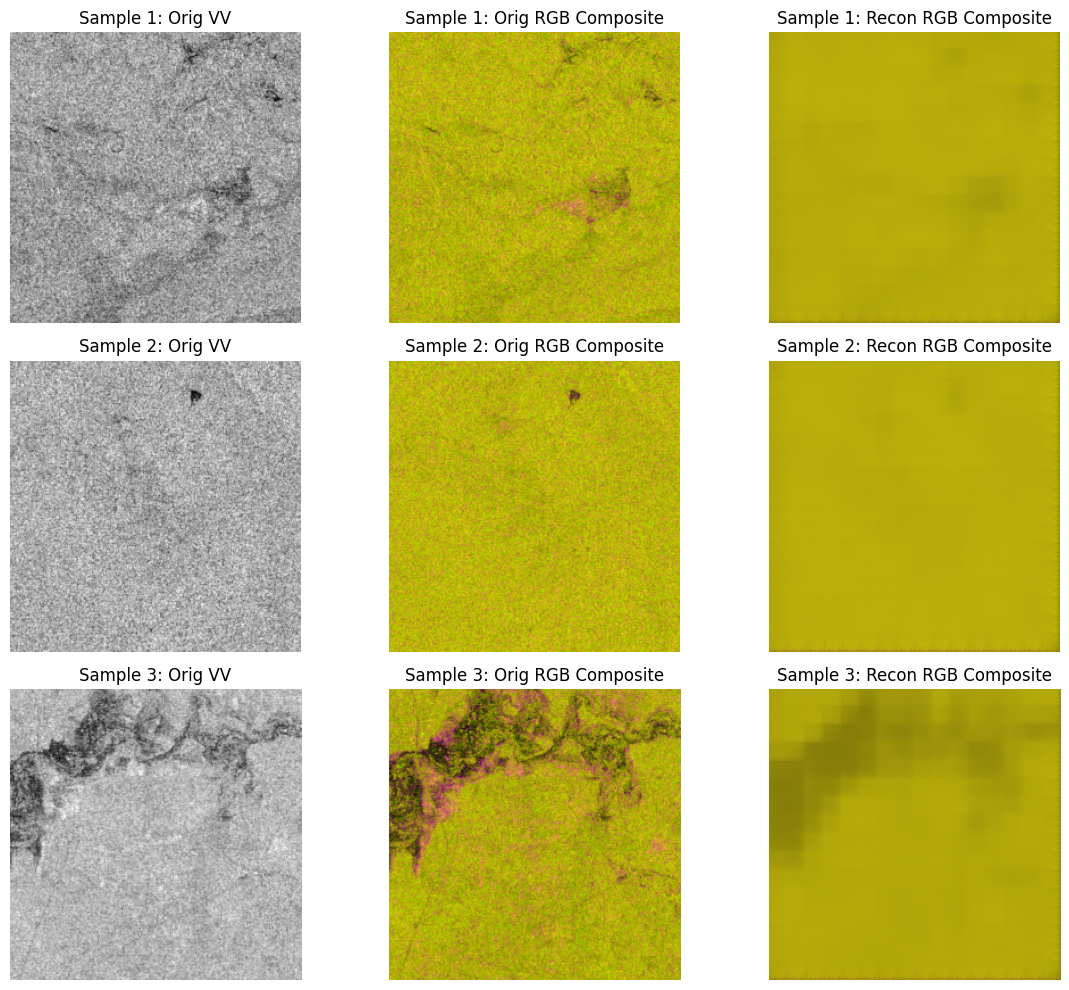

In [6]:
# Plot training loss curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs+1), loss_history, marker='o', color='#1f77b4', linewidth=2)
plt.title("Autoencoder Reconstruction Training Loss Curve", fontsize=12, pad=10)
plt.xlabel("Epoch", fontsize=10)
plt.ylabel("MSE Loss", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# helper to build an RGB composite from normalized VV (band 0) and VH (band 1)
def make_s1_rgb(img_tensor):
    vv = img_tensor[0].cpu().numpy()
    vh = img_tensor[1].cpu().numpy()
    # Blue channel: difference of normalized bands to capture backscatter ratio
    diff = np.clip(vv - vh, 0, 1)
    
    # Stack to get RGB shape [H, W, 3]
    rgb = np.stack([vv, vh, diff], axis=-1)
    return rgb

# Pick 3 sample images from the test set for visualization
model.eval()
test_samples = [test_dataset[i] for i in [0, 2, 4]]

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for idx, (img, _) in enumerate(test_samples):
    img_device = img.unsqueeze(0).to(device)
    with torch.no_grad():
        reconstructed, _ = model(img_device)
        reconstructed = reconstructed.squeeze(0)
        
    # Make RGBs
    orig_rgb = make_s1_rgb(img)
    recon_rgb = make_s1_rgb(reconstructed)
    
    # Original VV Band (Grayscale)
    axes[idx, 0].imshow(img[0].cpu().numpy(), cmap='gray')
    axes[idx, 0].set_title(f"Sample {idx+1}: Orig VV")
    axes[idx, 0].axis('off')
    
    # Original Composite (RGB)
    axes[idx, 1].imshow(orig_rgb)
    axes[idx, 1].set_title(f"Sample {idx+1}: Orig RGB Composite")
    axes[idx, 1].axis('off')
    
    # Reconstructed Composite (RGB)
    axes[idx, 2].imshow(recon_rgb)
    axes[idx, 2].set_title(f"Sample {idx+1}: Recon RGB Composite")
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()

### 🛠️ Step 7: Feature Extraction
We will now use the trained **Encoder** as a spatial feature extractor. 
1. We pass each S1 image through the Encoder to get a latent feature map of shape `[128, 16, 16]`.
2. We upsample this low-resolution feature map back to the original image scale of `256x256` using bilinear interpolation. This yields 128 spatial features per pixel.
3. We concatenate these features with the original `2` normalized bands (VV, VH), giving a **130-dimensional feature vector** for each pixel.
4. To train a classifier quickly and prevent memory bloat, we downsample/subsample a representative set of pixels from our training images.

In [7]:
def extract_pixel_dataset(dataset, model, max_pixels_per_img=5000):
    """Extract 130-dim pixel feature vectors and corresponding labels"""
    model.eval()
    all_features = []
    all_labels = []
    
    for idx in range(len(dataset)):
        img, label = dataset[idx]
        img_device = img.unsqueeze(0).to(device)
        
        with torch.no_grad():
            # Extract features using encoder
            latent = model.encoder(img_device) # shape: [1, 128, 16, 16]
            # Upsample back to 256x256
            feat_upsampled = torch.nn.functional.interpolate(
                latent, size=(256, 256), mode='bilinear', align_corners=False
            ) # shape: [1, 128, 256, 256]
            
            # Concatenate with original normalized bands
            full_feat = torch.cat([img_device, feat_upsampled], dim=1).squeeze(0) # shape: [130, 256, 256]
            
        # Convert to numpy arrays
        full_feat_np = full_feat.cpu().numpy() # [130, 256, 256]
        label_np = label.cpu().numpy() # [256, 256]
        
        # Flatten pixels: shape [256*256, 130] and [256*256]
        flat_feats = full_feat_np.reshape(130, -1).T
        flat_labels = label_np.reshape(-1)
        
        # Filter valid labels (ignore label -1)
        valid_indices = np.where(flat_labels >= 0)[0]
        
        if len(valid_indices) == 0:
            continue
            
        flat_feats = flat_feats[valid_indices]
        flat_labels = flat_labels[valid_indices]
        
        # Subsample to avoid memory issues and speed up classifier training
        if len(flat_feats) > max_pixels_per_img:
            selected = np.random.choice(len(flat_feats), max_pixels_per_img, replace=False)
            flat_feats = flat_feats[selected]
            flat_labels = flat_labels[selected]
            
        all_features.append(flat_feats)
        all_labels.append(flat_labels)
        
    return np.vstack(all_features), np.concatenate(all_labels)

print("Extracting pixel-wise training features...")
X_train, y_train = extract_pixel_dataset(train_dataset, model, max_pixels_per_img=2000)
print(f"X_train Shape: {X_train.shape}, y_train Shape: {y_train.shape}")
print(f"Flood pixel ratio in training: {np.mean(y_train == 1):.2%}")

Extracting pixel-wise training features...


X_train Shape: (56470, 130), y_train Shape: (56470,)
Flood pixel ratio in training: 4.07%


### 🌲 Step 8: Pixel-Wise Classification using Random Forest
With our pixel feature matrix extracted, we train a **Random Forest Classifier** from `scikit-learn`. 
The classifier will learn to classify each pixel as either **Non-Flooded** (`0`) or **Flooded** (`1`) using the 130-dimensional combination of original radar backscatter and learned spatial-contextual features.

In [8]:
# Instantiate and train Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
print("Training Random Forest Classifier on pixel features...")
rf_classifier.fit(X_train, y_train)
print("Classifier training complete!")

Training Random Forest Classifier on pixel features...


Classifier training complete!


### 📊 Step 9: Performance Evaluation and Inference
Now, we run pixel-wise classification inference on our test subset. For each test image:
1. Extract the full 130-dimensional feature map.
2. Flatten and predict the labels using the Random Forest classifier.
3. Reshape predictions back to a 256x256 spatial mask.
4. Calculate pixel-wise metrics (Accuracy, Precision, Recall, F1, and Intersection over Union/Jaccard Index) on valid pixels (excluding `-1` no-data regions).

In [9]:
# Perform test feature extraction (without pixel subsampling to get full spatial predictions)
test_predictions = []
test_true_labels = []

# To aggregate for overall metric calculation
all_y_true = []
all_y_pred = []

model.eval()
for idx in range(len(test_dataset)):
    img, label = test_dataset[idx]
    img_device = img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        latent = model.encoder(img_device)
        feat_upsampled = torch.nn.functional.interpolate(
            latent, size=(256, 256), mode='bilinear', align_corners=False
        )
        full_feat = torch.cat([img_device, feat_upsampled], dim=1).squeeze(0)
        
    full_feat_np = full_feat.cpu().numpy().reshape(130, -1).T
    label_np = label.cpu().numpy()
    flat_label = label_np.reshape(-1)
    
    # Predict all pixels in the image
    pred_flat = rf_classifier.predict(full_feat_np)
    pred_spatial = pred_flat.reshape(256, 256)
    
    test_predictions.append(pred_spatial)
    test_true_labels.append(label_np)
    
    # Save valid indices for global metric summary
    valid_idx = np.where(flat_label >= 0)[0]
    all_y_true.extend(flat_label[valid_idx])
    all_y_pred.extend(pred_flat[valid_idx])

# Convert to numpy arrays for calculation
all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

# Calculate global metrics
accuracy = accuracy_score(all_y_true, all_y_pred)
precision = precision_score(all_y_true, all_y_pred)
recall = recall_score(all_y_true, all_y_pred)
f1 = f1_score(all_y_true, all_y_pred)
iou = jaccard_score(all_y_true, all_y_pred) # Intersection over Union

print("=== GLOBAL CLASSIFICATION METRICS ON TEST SET ===")
print(f"Overall Accuracy : {accuracy:.4f}")
print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"F1-Score         : {f1:.4f}")
print(f"IoU (Jaccard ID) : {iou:.4f}")
print("================================================")

=== GLOBAL CLASSIFICATION METRICS ON TEST SET ===
Overall Accuracy : 0.9383
Precision        : 0.8605
Recall           : 0.3810
F1-Score         : 0.5282
IoU (Jaccard ID) : 0.3588


### 📈 Visualizing Confusion Matrix and Flood Predictions
We plot the global **Confusion Matrix** to see the distribution of true positives, true negatives, false positives, and false negatives.
Finally, we display several test sample predictions side-by-side with their corresponding Sentinel-1 False-Color RGB composites and Ground Truth flood masks.

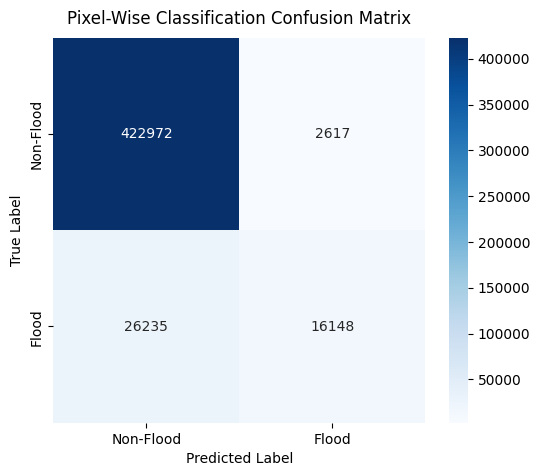

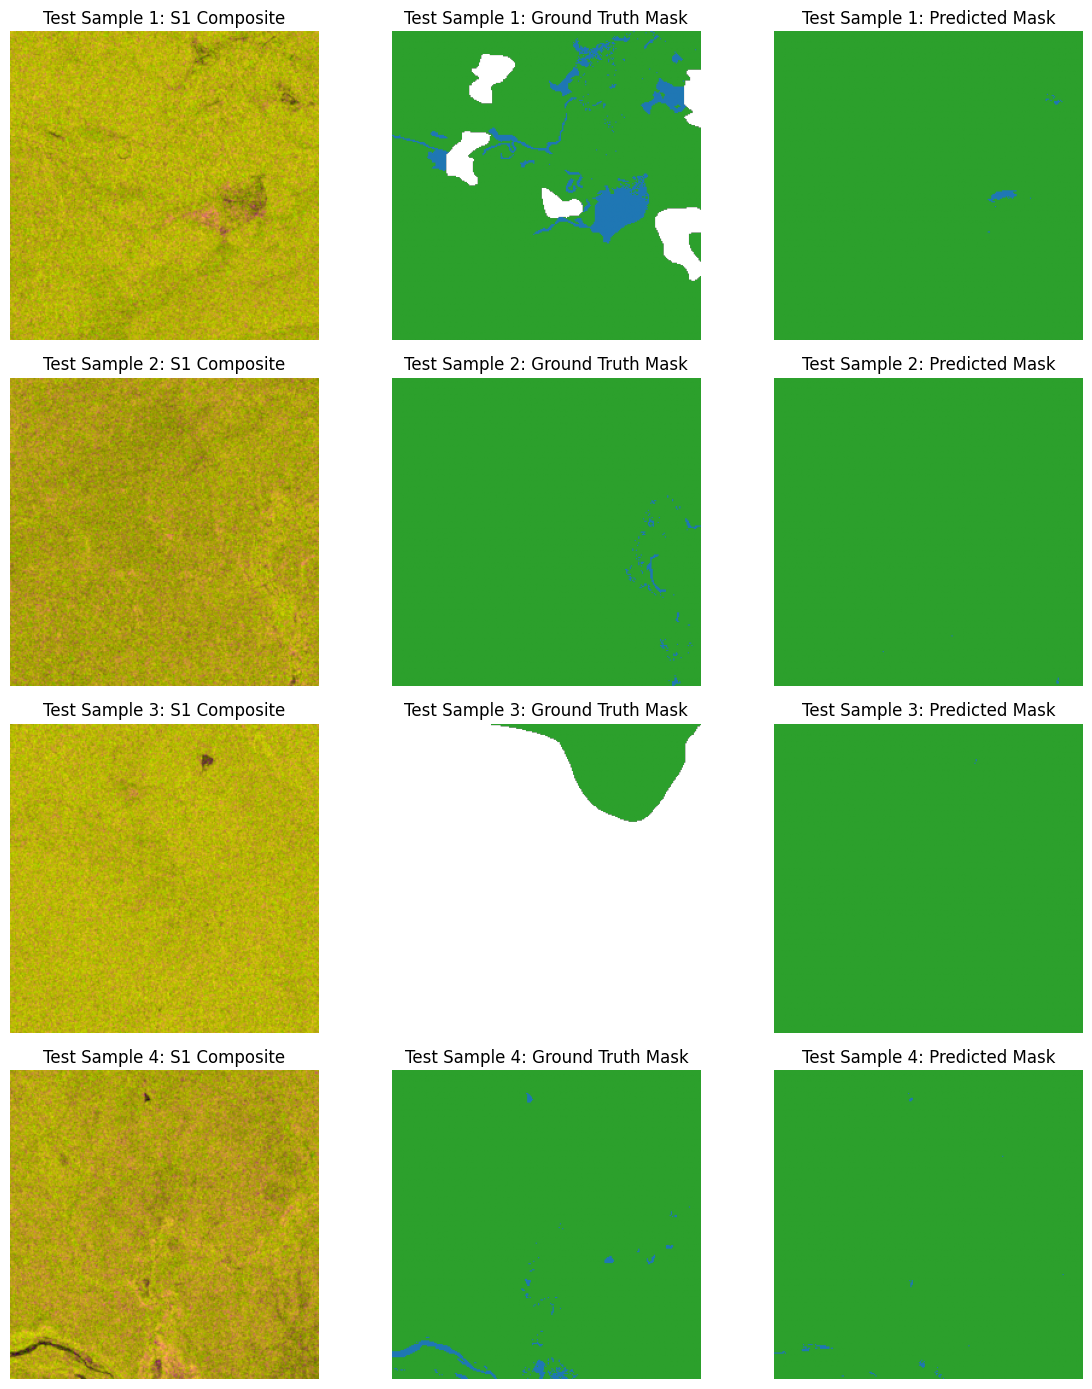

In [10]:
# Plot Confusion Matrix
cm = confusion_matrix(all_y_true, all_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Flood', 'Flood'], 
            yticklabels=['Non-Flood', 'Flood'])
plt.title("Pixel-Wise Classification Confusion Matrix", fontsize=12, pad=10)
plt.xlabel("Predicted Label", fontsize=10)
plt.ylabel("True Label", fontsize=10)
plt.show()

# Plot predictions side-by-side
fig, axes = plt.subplots(4, 3, figsize=(12, 14))

# Color palette for labels: -1 = Black/Grey, 0 = Green, 1 = Blue
from matplotlib.colors import ListedColormap
# Custom colormap for labels: 0=Green (Land), 1=Blue (Water)
cmap_label = ListedColormap(['#2ca02c', '#1f77b4'])

for idx in range(4): # Show first 4 test samples
    img, label = test_dataset[idx]
    pred = test_predictions[idx]
    
    # Create RGB composite of original SAR image
    rgb_s1 = make_s1_rgb(img)
    
    # Raw Sentinel-1 Composite
    axes[idx, 0].imshow(rgb_s1)
    axes[idx, 0].set_title(f"Test Sample {idx+1}: S1 Composite")
    axes[idx, 0].axis('off')
    
    # Ground Truth Mask (map -1 to nan so it shows up differently or ignore)
    lbl_np = label.cpu().numpy().astype(float)
    lbl_np[lbl_np < 0] = np.nan # Hide invalid pixels
    axes[idx, 1].imshow(lbl_np, cmap=cmap_label, vmin=0, vmax=1)
    axes[idx, 1].set_title(f"Test Sample {idx+1}: Ground Truth Mask")
    axes[idx, 1].axis('off')
    
    # Predicted Mask
    axes[idx, 2].imshow(pred, cmap=cmap_label, vmin=0, vmax=1)
    axes[idx, 2].set_title(f"Test Sample {idx+1}: Predicted Mask")
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()